In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,60,23,73
1,2,Male,36,15,78
2,3,Male,39,32,84
3,4,Male,38,15,68
4,5,Male,61,21,52


In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']]

In [6]:
print(df.isnull().sum())
X = X.dropna()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

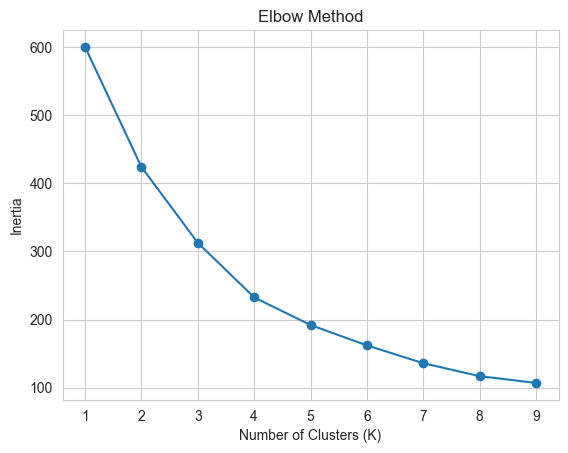

In [8]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = labels

In [10]:
print("Inertia:", kmeans.inertia_)

Inertia: 312.62851922236524


In [11]:
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.3200492712198739


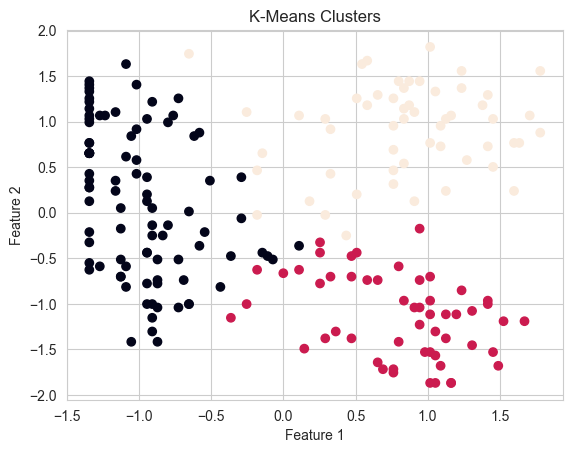

In [12]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clusters")
plt.show()

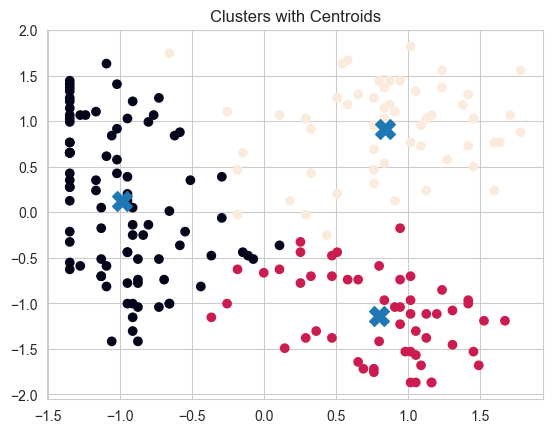

In [13]:
centroids = kmeans.cluster_centers_

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200)
plt.title("Clusters with Centroids")
plt.show()